## Análisis de datos II - Clase 2
---

## SHAP
---


SHAP permite explicar la **contribución de las features** en un problema de ML.
En esta notebook vamos a ver cómo usar SHAP e interpretar algunas visualizaciones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
import shap

### DATOS

Vamos a trabajar con el dataset [diabetes](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset) disponible en sklearn.

- El dataset tiene 10 variables: edad, sexo, índice de masa corporal (bmi), presión sanguínea promedio (bp) y otras 6 mediciones de parámetros del suero sanguíneo.
- La variable target es una medida cuantitativa de la progresión de la enfermedad después de un año de un baseline.
- Las features están estandarizadas.

In [3]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)

X = diabetes.data
y = diabetes.target

In [4]:
# X, y = shap.datasets.diabetes()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_test.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
362,0.019913,0.050680,0.104809,0.070072,-0.035968,-0.026679,-0.024993,-0.002592,0.003709,0.040343
249,-0.012780,-0.044642,0.060618,0.052858,0.047965,0.029375,-0.017629,0.034309,0.070207,0.007207
271,0.038076,0.050680,0.008883,0.042529,-0.042848,-0.021042,-0.039719,-0.002592,-0.018114,0.007207
435,-0.012780,-0.044642,-0.023451,-0.040099,-0.016704,0.004636,-0.017629,-0.002592,-0.038460,-0.038357
400,-0.023677,-0.044642,0.045529,0.090729,-0.018080,-0.035447,0.070730,-0.039493,-0.034522,-0.009362


In [5]:
X_train.shape

(353, 10)

In [6]:
X_test.shape

(89, 10)

### EDA básico

In [7]:
df = X.copy()
df["target"] = y

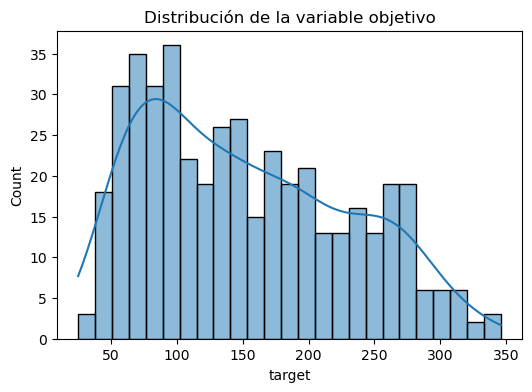

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df["target"], bins=25, kde=True)
plt.title("Distribución de la variable objetivo")
plt.show()

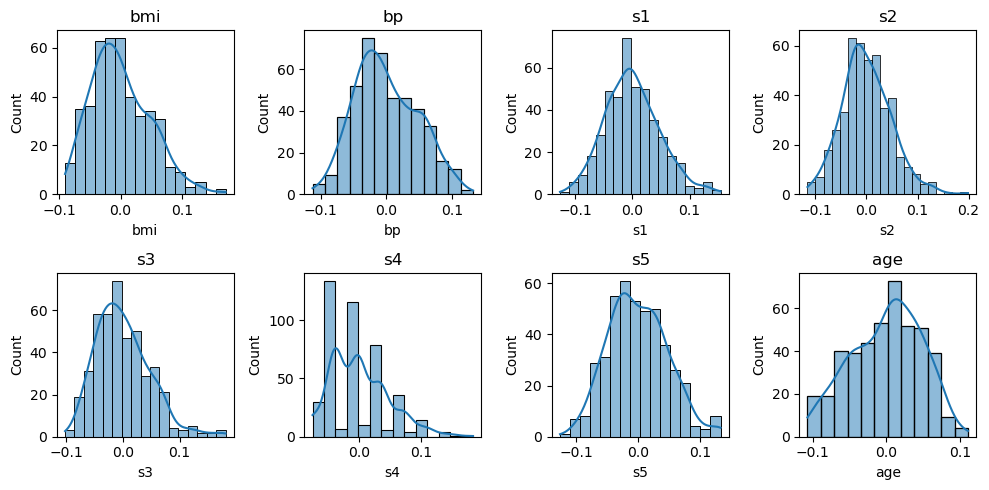

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(10,5))

cols = ["bmi", "bp", "s1", "s2", "s3", "s4", "s5", "age"]

for ax, col in zip(axes.ravel(), cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()

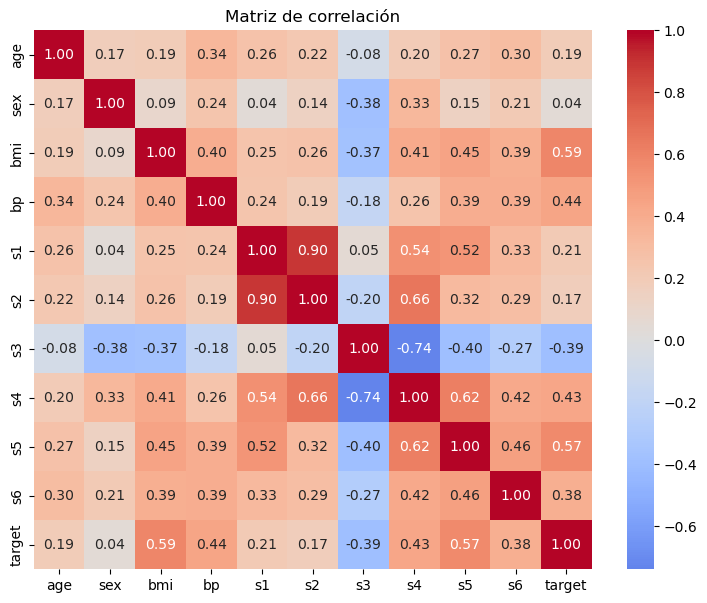

In [10]:
plt.figure(figsize=(9,7))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.show()

**Observaciones**

Estos gráficos permiten anticipar qué variables deberían ser relevantes para el modelo. En principio,
ya se ve que bmi y s5 tienen buena correlación con target. Además, algunas variables están correlacionadas entre sí.

### Entrenamos un árbol simple

In [11]:
modelo = DecisionTreeRegressor(max_depth=3,random_state=42)

modelo.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [12]:
y_pred = modelo.predict(X_test)

print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²  : {r2_score(y_test, y_pred):.3f}")

MAE : 54.65
RMSE: 68.34
R²  : 0.089


---
### SHAP

Creamos el explainer.
La elección del algoritmo depende principalmente de la familia del modelo.


| Tipo de modelo | Explainer sugerido |
|----------------|--------------------|
| Regresión lineal, Ridge, Lasso | `LinearExplainer` |
| Árboles, Random Forest, XGBoost, LightGBM, CatBoost | `TreeExplainer` |
| Redes neuronales | `DeepExplainer` o `GradientExplainer` |
| Otros modelos: SVM, KNN, modelos propios, etc. | Explainers genéricos como `KernelExplainer` o `PermutationExplainer` |


Cuando no sabemos qué explainer usar, podemos invocar a `shap.Explainer`, que intenta elegir el mejor explainer disponible para el modelo.

In [13]:
explainer = shap.Explainer(modelo.predict, X_train)
explanation = explainer(X_test)

In [14]:
explanation.shape # En el caso de regresión: (n_samples, n_features)

(89, 10)

In [15]:
shap_values     = explanation.values          # los valores SHAP
expected_values = explanation.base_values     # valor base (expected value)
data            = explanation.data            # los valores originales de X
feature_names   = explanation.feature_names   # nombres de las variables

In [16]:
shap_values[:3] # las primeras tres muestras

array([[ 3.55271368e-15, -7.99360578e-15,  4.63239060e+01,
         2.92997181e+01,  6.21724894e-15,  1.24344979e-14,
         2.56228889e+00,  5.32907052e-15, -1.98149698e+01,
         0.00000000e+00],
       [ 1.77635684e-14, -2.66453526e-15,  5.68765072e+01,
         7.40629221e+00,  8.88178420e-16,  2.66453526e-15,
         1.67534274e+00,  2.66453526e-15,  3.60504634e+01,
         0.00000000e+00],
       [ 2.48689958e-14, -4.44089210e-15,  3.23537631e+01,
         2.50777538e+01,  6.21724894e-15,  9.76996262e-15,
         2.56228889e+00,  4.44089210e-15, -1.62286267e+00,
         0.00000000e+00]])

In [17]:
expected_values[0]

161.2199659507162

#### Cómo contribuyen las features a la predicción

In [18]:
print("Observación (la primera del dataset de test):")
display(X_test.iloc[[0]])

print(f"Valor real: {y_test.iloc[0]}")
print(f"Predicción: {y_pred[0]:.2f}")

Observación (la primera del dataset de test):


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
362,0.019913,0.05068,0.104809,0.070072,-0.035968,-0.026679,-0.024993,-0.002592,0.003709,0.040343


Valor real: 321.0
Predicción: 219.59


#### Explicación SHAP

In [19]:
exp_1muestra = explanation[0, :] # primera muestra, todas las features
exp_1muestra

.values =
array([ 3.55271368e-15, -7.99360578e-15,  4.63239060e+01,  2.92997181e+01,
        6.21724894e-15,  1.24344979e-14,  2.56228889e+00,  5.32907052e-15,
       -1.98149698e+01,  0.00000000e+00])

.base_values =
161.2199659507162

.data =
array([ 0.01991321,  0.05068012,  0.10480869,  0.0700723 , -0.03596778,
       -0.0266789 , -0.02499266, -0.00259226,  0.00370906,  0.04034337])

In [20]:
print("Predicción (base + SHAP values):",exp_1muestra.base_values + exp_1muestra.values.sum())

Predicción (base + SHAP values): 219.59090909090946


---
## Waterfall plot

Los **waterfall plots**  explican cómo el modelo llega a la predicción de una observación. Parten del valor base E[f(x)] (la predicción promedio del modelo) y muestran cómo cada feature, a través de su SHAP value, aumenta o disminuye ese valor hasta alcanzar la predicción final f(x).

Notar que la suma del valor base y de todos los SHAP values coincide con la predicción del modelo.

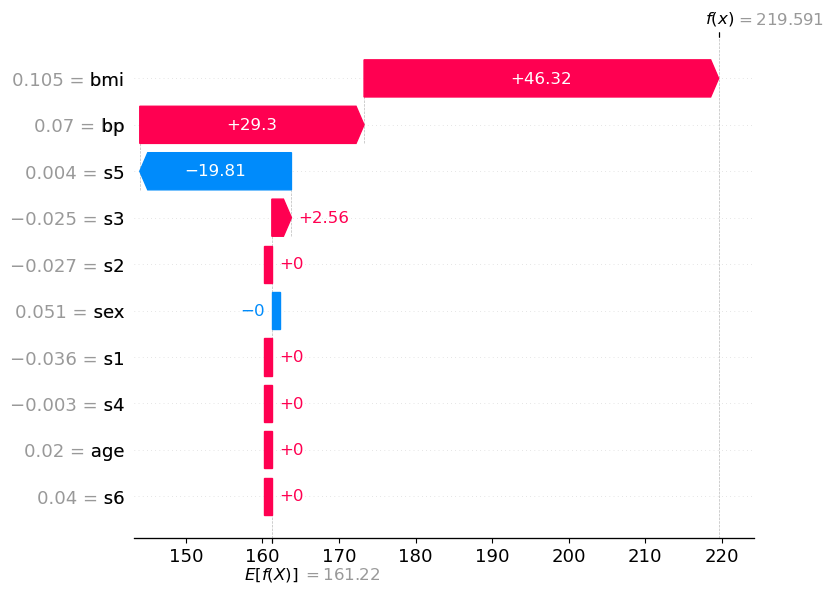

In [21]:
shap.plots.waterfall(exp_1muestra)

---
## Beeswarm plot

El **beeswarm plot** es una visualización de todos los SHAP values.

El plot muestra la relación entre los valores de las features y los shape values.

Cuidado! El color no corresponde al SHAP value, sino al valor de las features.


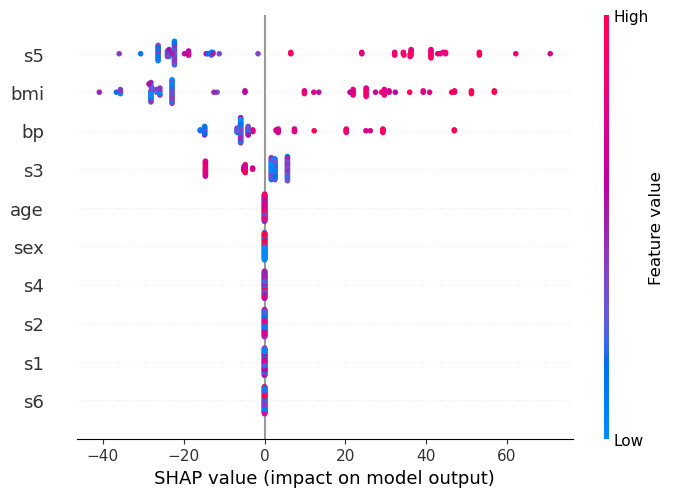

In [22]:
shap.plots.beeswarm(explanation)